In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('salaries.csv')

df.head()

,Timestamp,Employer,Location,Job Title,Years at Employer,Years of Experience,Annual Base Pay,Signing Bonus,Annual Bonus,Annual Stock Value/Bonus,Gender,Additional Comments
0,3/21/2016 12:54:49,NaN,"Raleigh, NC",Software Developer,NaN,18,122000,NaN,NaN,NaN,Male,NaN
1,3/21/2016 12:58:52,Opower,"San Francisco, CA",Systems Engineer,2,13,125000,5000,0,5000 shares,Male,Don't work here.
2,3/21/2016 12:58:57,NaN,San Diego CA,Systems engineer,1,1 of employment,"83,000",0,$50.00,0,Male,NaN
3,3/21/2016 12:58:58,Walmart,"Bentonville, AR",Senior Developer,8,15,"65,000",NaN,"5,000","3,000",Male,NaN
4,3/21/2016 12:59:11,Vertical Knowledge,"Cleveland, OH",Software Engineer,1,4,86000,5000,6000,0,Male,NaN


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3711 entries, 0 to 3710
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Timestamp                 3711 non-null   str  
 1   Employer                  1968 non-null   str  
 2   Location                  3207 non-null   str  
 3   Job Title                 3710 non-null   str  
 4   Years at Employer         3338 non-null   str  
 5   Years of Experience       3382 non-null   str  
 6   Annual Base Pay           3710 non-null   str  
 7   Signing Bonus             2450 non-null   str  
 8   Annual Bonus              2614 non-null   str  
 9   Annual Stock Value/Bonus  2191 non-null   str  
 10  Gender                    3526 non-null   str  
 11  Additional Comments       521 non-null    str  
dtypes: str(12)
memory usage: 624.8 KB


Timestamp                      0
Employer                    1743
Location                     504
Job Title                      1
Years at Employer            373
Years of Experience          329
Annual Base Pay                1
Signing Bonus               1261
Annual Bonus                1097
Annual Stock Value/Bonus    1520
Gender                       185
Additional Comments         3190
dtype: int64

In [4]:
df = df.dropna()

In [6]:
print(df.columns)

Index(['Timestamp', 'Employer', 'Location', 'Job Title', 'Years at Employer',
       'Years of Experience', 'Annual Base Pay', 'Signing Bonus',
       'Annual Bonus', 'Annual Stock Value/Bonus', 'Gender',
       'Additional Comments'],
      dtype='str')


In [7]:
[col for col in df.columns if 'sal' in col.lower()]

[]

In [10]:
print(df.columns)

Index(['Timestamp', 'Employer', 'Location', 'Job Title', 'Years at Employer',
       'Years of Experience', 'Annual Base Pay', 'Signing Bonus',
       'Annual Bonus', 'Annual Stock Value/Bonus', 'Gender',
       'Additional Comments'],
      dtype='str')


In [15]:
print(locals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', 'import pandas as pd\nimport numpy as np\n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\nfrom sklearn.tree import DecisionTreeRegressor\nfrom sklearn.ensemble import RandomForestRegressor\nfrom sklearn.metrics import mean_squared_error, r2_score', "df = pd.read_csv('salaries.csv')\n\ndf.head()", 'df.info()\ndf.describe()\ndf.isnull().sum()', 'df = df.dropna()', "X = df.drop('salary', axis=1)\ny = df['salary']", 'print(df.columns)', "[col for col in df.columns if 'sal' in col.lower()]", 'X_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)', 'print(type(X), type(y))\nprint(X.shape, y.shape)', 'print(df.columns)', 'print("

In [19]:
df.head()

,Timestamp,Employer,Location,Job Title,Years at Employer,Years of Experience,Annual Base Pay,Signing Bonus,Annual Bonus,Annual Stock Value/Bonus,Gender,Additional Comments
1,3/21/2016 12:58:52,Opower,"San Francisco, CA",Systems Engineer,2,13,125000,5000,0,5000 shares,Male,Don't work here.
48,3/21/2016 13:07:03,NBC Universal,New York,Senior Analyst,1.5,2,55000,0,0,0,Male,Dont go there
50,3/21/2016 13:07:22,30 person startup,San Francisco,Software Engineer,2,5,125000,0,0,0,Male,options were granted but have no real monetary...
62,3/21/2016 13:09:25,Early-Stage Startup,"Stockholm, Sweden",iOS Developer,0.8,8,36.5K USD / YEAR,0,0,0,Male,"Yup. That's what I make. And trust me, I'm a p..."
91,3/21/2016 13:12:07,Freelance,"Denver, CO",Software Engineer,11,20,190000,0,0,0,Male,Estimated - bill @ $145-180/hr; don't work yea...


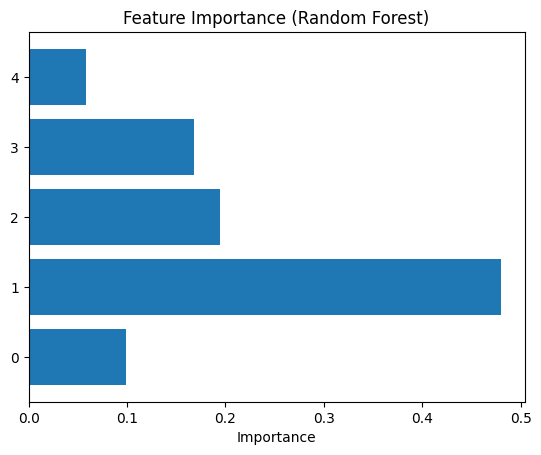

In [22]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

# Create sample data
X, y = make_regression(n_samples=100, n_features=5, random_state=42)

# Model
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# Feature importance
importance = rf_model.feature_importances_

# Plot
plt.barh(range(len(importance)), importance)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [24]:
import pandas as pd

X = pd.DataFrame(X)
sample = X.iloc[0].values.reshape(1, -1)